### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### loading data

In [2]:
df=pd.read_csv("datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv")

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
C:\Users\ahmed\AppData\Local\Temp\ipykernel_8088\1300445309.py:1: SyntaxWarning: invalid escape sequence '\W'
  df=pd.read_csv("datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv")


### Data cleaning

In [3]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5580,8859-YSTWS,Male,0,No,No,48,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.95,1004.5,No
3961,7421-ZLUPA,Female,0,No,No,8,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,29.25,226.95,No
388,8782-LKFPK,Male,0,No,No,44,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Mailed check,90.40,4063,No
5875,2296-DKZFP,Female,0,Yes,No,65,Yes,No,DSL,Yes,...,Yes,No,No,Yes,Two year,No,Bank transfer (automatic),71.00,4386.2,No
5416,8961-QDZZJ,Female,0,Yes,Yes,57,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,One year,Yes,Electronic check,95.00,5535.8,No
1056,6941-PMGEP,Female,0,No,No,5,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,80.00,412.5,Yes
529,0356-OBMAC,Female,1,No,No,56,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),99.90,5706.3,No
6658,0818-OCPZO,Male,1,No,No,27,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,81.45,2122.05,Yes
2663,5140-FOMCQ,Female,0,Yes,No,59,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),109.15,6557.75,No
6714,7315-WYOAW,Male,0,No,No,13,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,No,Electronic check,100.75,1313.25,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.duplicated().any()

False

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df.dropna(subset=['TotalCharges'],inplace=True)

### EDA

In [11]:
gen=df['gender'].value_counts().reset_index()
gen

,gender,count
0,Male,3549
1,Female,3483


<Axes: xlabel='Churn', ylabel='SeniorCitizen'>

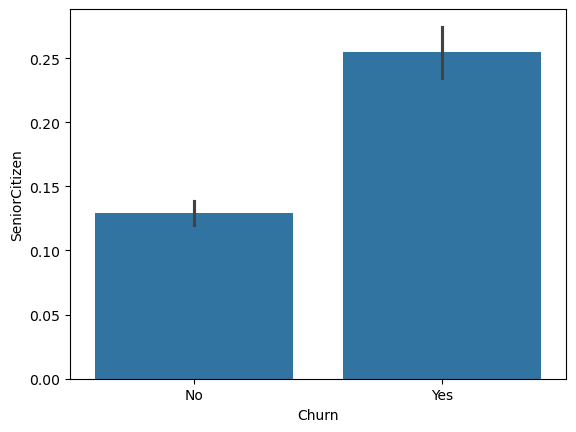

In [12]:
sns.barplot(df,x="Churn",y='SeniorCitizen')

In [13]:
df['SeniorCitizen']=pd.to_numeric(df['SeniorCitizen'],errors="coerce")

In [14]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [15]:
mask=df['Churn']=='Yes'
churnDf=df[mask]
nonchurndf=df[~mask]

In [16]:
for col in churnDf.columns:
    print(churnDf[col].value_counts())

customerID
3668-QPYBK    1
6633-MPWBS    1
6532-YLWSI    1
7067-KSAZT    1
0511-JTEOY    1
             ..
0235-KGSLC    1
1846-XWOQN    1
5103-MHMHY    1
4094-NSEDU    1
8361-LTMKD    1
Name: count, Length: 1869, dtype: int64
gender
Female    939
Male      930
Name: count, dtype: int64
SeniorCitizen
0    1393
1     476
Name: count, dtype: int64
Partner
No     1200
Yes     669
Name: count, dtype: int64
Dependents
No     1543
Yes     326
Name: count, dtype: int64
tenure
1     380
2     123
3      94
4      83
5      64
     ... 
60      6
72      6
62      5
64      4
63      4
Name: count, Length: 72, dtype: int64
PhoneService
Yes    1699
No      170
Name: count, dtype: int64
MultipleLines
Yes                 850
No                  849
No phone service    170
Name: count, dtype: int64
InternetService
Fiber optic    1297
DSL             459
No              113
Name: count, dtype: int64
OnlineSecurity
No                     1461
Yes                     295
No internet service     113
Na

### insights

1. non senior cetizen curn more
2. who has not partner churns mor
3. phone services has a problem
4. internet services may has a probelm in fiber optics has a problem 
5. month to month more churns
6. papers bills problem may we can facliate electronic paymnts 
7. we have a problem in elctronic check payments 

### Doing some Visuals

<Axes: xlabel='SeniorCitizen', ylabel='count'>

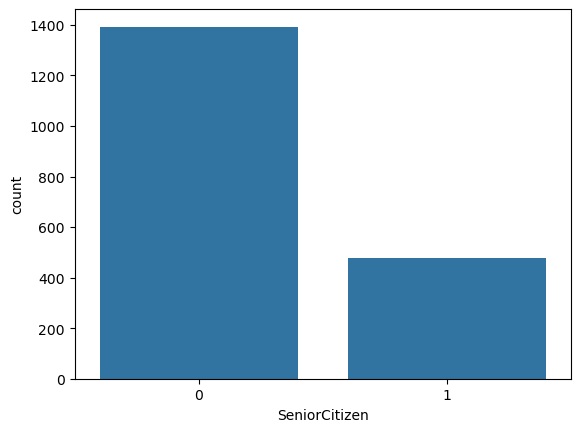

In [17]:
sns.barplot(churnDf['SeniorCitizen'].value_counts().reset_index(),x='SeniorCitizen',y='count')

<Axes: xlabel='Partner', ylabel='count'>

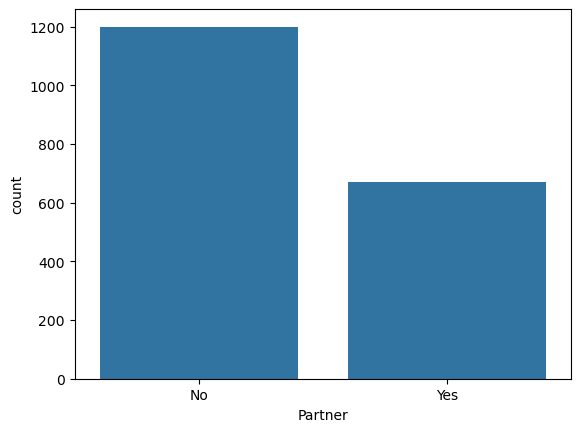

In [18]:
sns.barplot(churnDf['Partner'].value_counts().reset_index(),x='Partner',y='count')

<Axes: xlabel='InternetService', ylabel='count'>

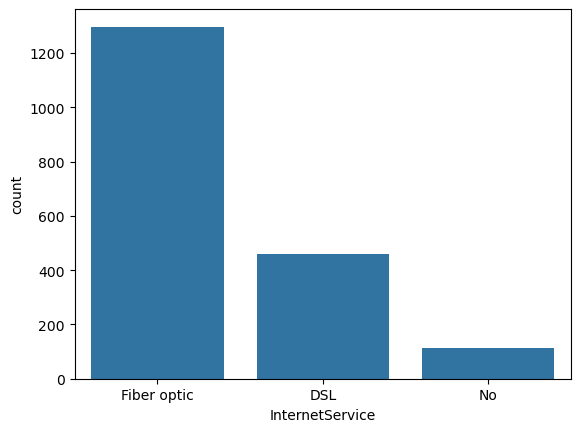

In [19]:
sns.barplot(churnDf['InternetService'].value_counts().reset_index(),x='InternetService',y='count')

<Axes: xlabel='PhoneService', ylabel='count'>

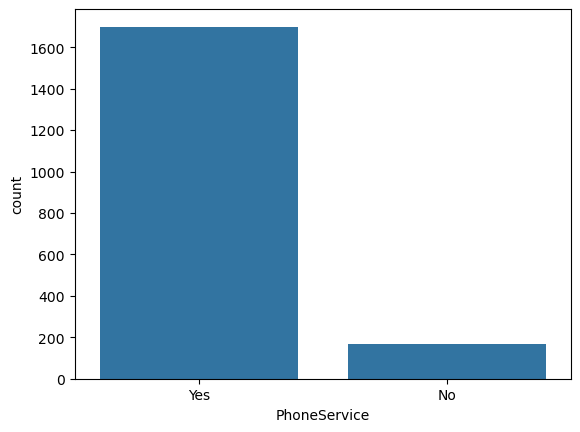

In [20]:
sns.barplot(churnDf['PhoneService'].value_counts().reset_index(),x='PhoneService',y='count')

<Axes: xlabel='Contract', ylabel='count'>

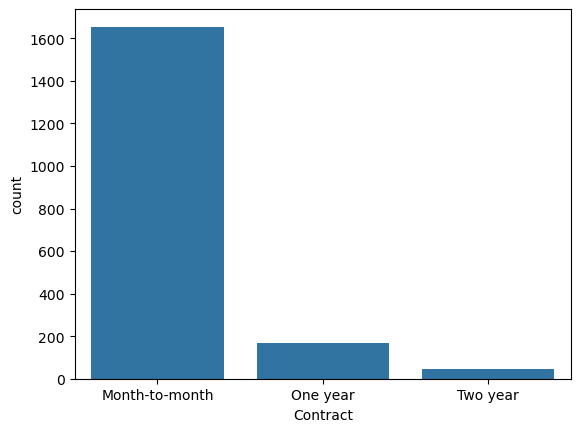

In [21]:
sns.barplot(churnDf['Contract'].value_counts().reset_index(),x='Contract',y='count')

<Axes: xlabel='PaperlessBilling', ylabel='count'>

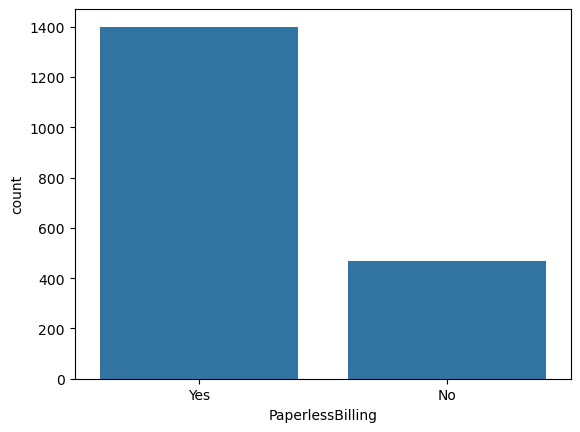

In [22]:
sns.barplot(churnDf['PaperlessBilling'].value_counts().reset_index(),x='PaperlessBilling',y='count')

<Axes: xlabel='PaymentMethod', ylabel='count'>

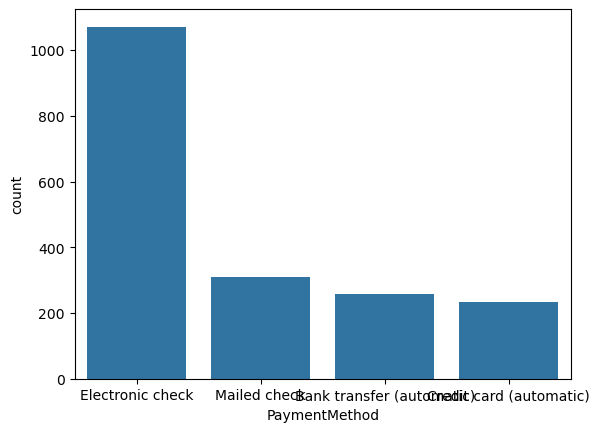

In [23]:
sns.barplot(churnDf['PaymentMethod'].value_counts().reset_index(),x='PaymentMethod',y='count')

<Axes: xlabel='Contract', ylabel='count'>

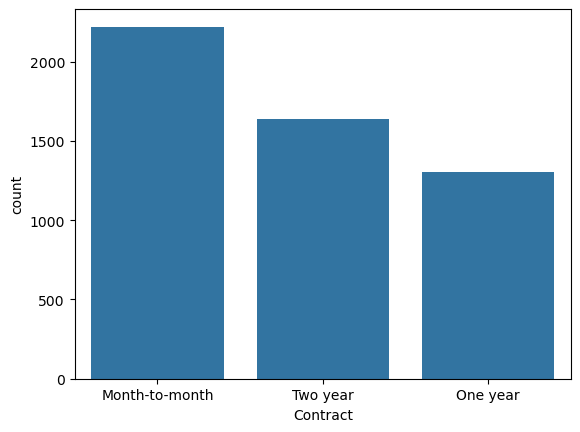

In [24]:
sns.barplot(nonchurndf['Contract'].value_counts().reset_index(),x='Contract',y='count')

C:\Users\ahmed\AppData\Local\Temp\ipykernel_8088\509600860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


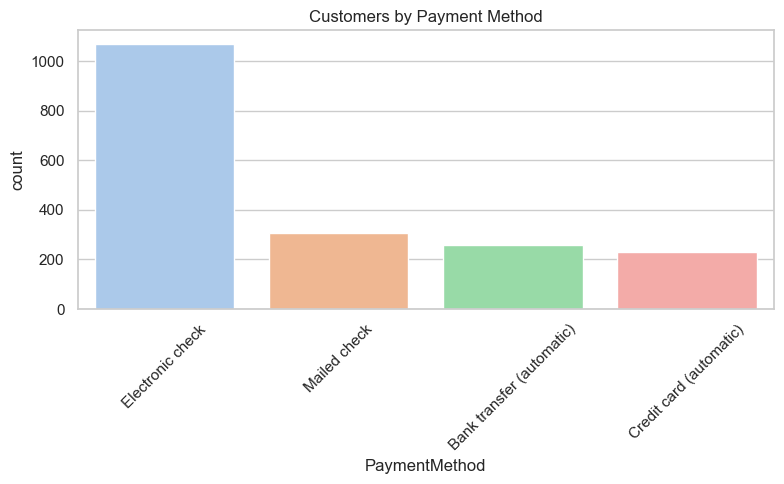

In [25]:
sns.set(style='whitegrid')
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churnDf['PaymentMethod'].value_counts().reset_index(),
    x='PaymentMethod', y='count', palette='pastel'
)
plt.xticks(rotation=45)
plt.title('Customers by Payment Method')
plt.tight_layout()
plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_8088\1177826808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


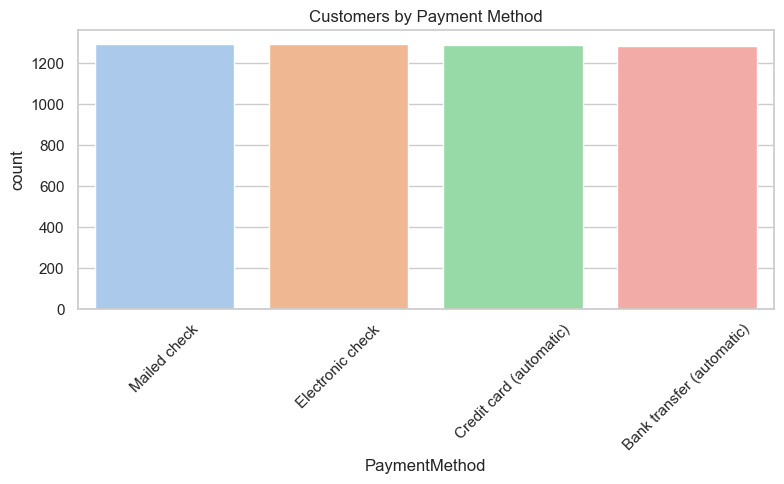

In [26]:
sns.set(style='whitegrid')
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=nonchurndf['PaymentMethod'].value_counts().reset_index(),
    x='PaymentMethod', y='count', palette='pastel'
)
plt.xticks(rotation=45)
plt.title('Customers by Payment Method')
plt.tight_layout()
plt.show()

In [27]:
#churnDf.to_csv("churn.csv")
#nonchurndf.to_csv("nonchurn.csv")

### preprocessing data

In [28]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [29]:
df.drop('customerID',axis=1,inplace=True)

In [30]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [31]:
cols=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})



In [32]:
cols2=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols2:
    df[col] = df[col].map({'Yes': 2, 'No': 1,"No internet service":0})


In [33]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 2, 'No': 1,'No phone service':0})

In [34]:
df['InternetService'] = df['InternetService'].map({'DSL': 2, 'No': 0,'Fiber optic':1})

In [35]:

df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1,'Two year':2})

In [36]:
df['PaymentMethod'] = df['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})


In [37]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Why because ther is error in encoding these columns

In [38]:
#df.drop(['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'],axis=1,inplace=True)

In [39]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [40]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

In [41]:
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [51]:
from imblearn.over_sampling import SMOTEN
somt=SMOTEN(random_state=42)
X_res, y_res = somt.fit_resample(x_scaled, y)

In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_res, y_res, test_size=0.30, random_state=42)

In [53]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [54]:
y_pred=model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.74      0.78      1563
           1       0.76      0.83      0.80      1535

    accuracy                           0.79      3098
   macro avg       0.79      0.79      0.79      3098
weighted avg       0.79      0.79      0.79      3098



In [58]:
from sklearn.ensemble import RandomForestClassifier
model2=RandomForestClassifier(n_estimators=100,random_state=42)
model2.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [60]:
y_pred=model2.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1563
           1       0.84      0.85      0.85      1535

    accuracy                           0.85      3098
   macro avg       0.85      0.85      0.85      3098
weighted avg       0.85      0.85      0.85      3098

